            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


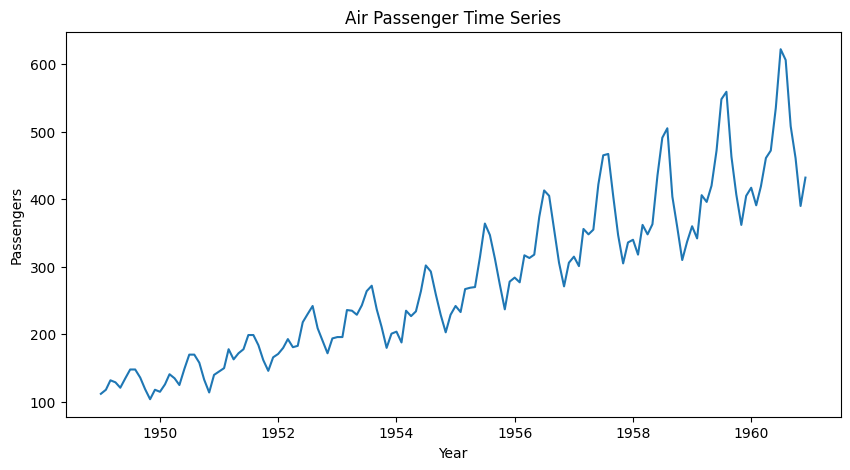

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


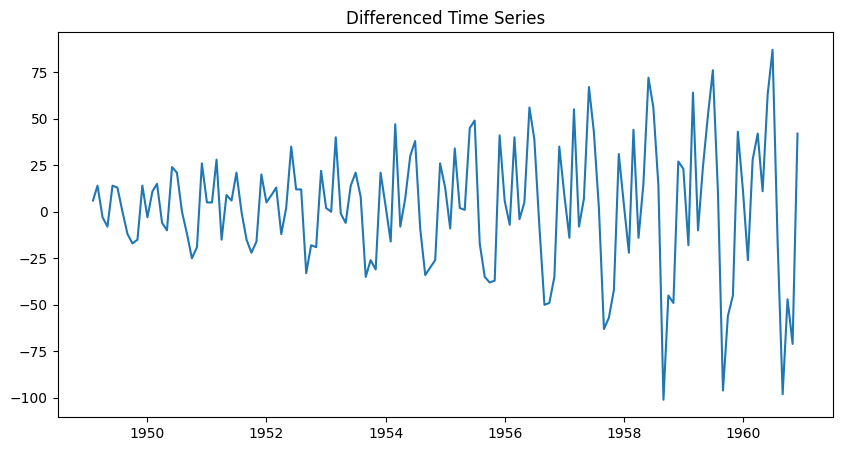

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

print(data.head())

# Plot time series
plt.figure(figsize=(10,5))
plt.plot(data['Passengers'])
plt.title("Air Passenger Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

# ADF Test
result = adfuller(data['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Differencing to make stationary
data_diff = data['Passengers'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(data_diff)
plt.title("Differenced Time Series")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Tue, 17 Mar 2026   AIC                           1394.683
Time:                        04:36:28   BIC                           1403.571
Sample:                    01-01-1949   HQIC                          1398.294
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

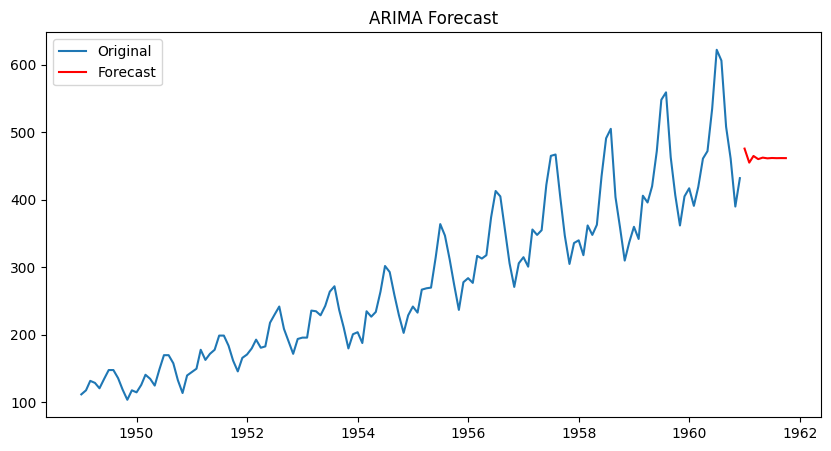

In [2]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(data['Passengers'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

# Forecast next 10 months
forecast = model_fit.forecast(steps=10)

print("Forecasted Values:")
print(forecast)

# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(data['Passengers'], label="Original")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()